This file is for backtesting 1 stock.

In [1]:
from ib_insync import *
import pandas as pd
import warnings
warnings.filterwarnings("ignore")



In [2]:
ib = IB()

In [3]:
util.startLoop()
ib.disconnect()
ib.connect('127.0.0.1', 7497, clientId = 200)

<IB connected to 127.0.0.1:7497 clientId=200>

In [4]:
ib.run()

In [5]:
def extract_info(accounts, tag):
    for acc in accounts:
        if tag == acc.tag:
            return acc.value
    return None

In [6]:
account = ib.accountSummary()
print("Net worth:", extract_info(account, "NetLiquidation"))
print("Cash:", extract_info(account, "TotalCashValue"))

Net worth: 1029249.28
Cash: 1016598.10


In [7]:
bars = ib.reqHistoricalData(
            # contract=Crypto('BTC', "PAXOS", "USD"), #, primaryExchange='NASDAQ'),
            contract=Stock('GOOG', 'SMART', 'USD', primaryExchange='NASDAQ'),
            endDateTime='',
            durationStr=f'{60 * 60 * 1} S',
            barSizeSetting='1 min',
            whatToShow='MIDPOINT',
            useRTH=True, 
            formatDate = 2
        )


In [8]:
util.df(bars)

,date,open,high,low,close,volume,average,barCount
0,2024-06-06 16:05:00+00:00,177.84,177.89,177.78,177.88,-1.0,-1.0,-1
1,2024-06-06 16:06:00+00:00,177.88,177.93,177.85,177.92,-1.0,-1.0,-1
2,2024-06-06 16:07:00+00:00,177.92,177.93,177.83,177.90,-1.0,-1.0,-1
3,2024-06-06 16:08:00+00:00,177.90,177.95,177.89,177.90,-1.0,-1.0,-1
4,2024-06-06 16:09:00+00:00,177.90,177.95,177.88,177.93,-1.0,-1.0,-1
...,...,...,...,...,...,...,...,...
56,2024-06-06 17:01:00+00:00,178.00,178.00,177.93,177.96,-1.0,-1.0,-1
57,2024-06-06 17:02:00+00:00,177.96,178.08,177.95,178.06,-1.0,-1.0,-1
58,2024-06-06 17:03:00+00:00,178.06,178.11,178.03,178.07,-1.0,-1.0,-1
59,2024-06-06 17:04:00+00:00,178.07,178.09,178.03,178.06,-1.0,-1.0,-1


Hold position
Current Price 499.59
RSI 67.82352053384315
Previous Stoch_RSI 43.819112984743896
Simple Moving Average 491.44952380952384 

Bollinger Lower Band 480.3760351327823
Bollinger Upper Band 502.5230124862654
The fee is: 1
Net Worth: 10000.0
Cash: 10000.0
Position: 0.0
Hold position
Current Price 498.59
RSI 65.69809739111854
Previous Stoch_RSI 27.969150252678155
Simple Moving Average 492.10809523809525 

Bollinger Lower Band 481.05932953405545
Bollinger Upper Band 503.15686094213504
The fee is: 1
Net Worth: 10000.0
Cash: 10000.0
Position: 0.0
Hold position
Current Price 499.72
RSI 66.958160810836
Previous Stoch_RSI 85.27294393240139
Simple Moving Average 492.64523809523814 

Bollinger Lower Band 481.2700594043589
Bollinger Upper Band 504.0204167861174
The fee is: 1
Net Worth: 10000.0
Cash: 10000.0
Position: 0.0
Hold position
Current Price 492.87
RSI 54.006702424890314
Previous Stoch_RSI 0.0
Simple Moving Average 492.9442857142857 

Bollinger Lower Band 481.8960907375079
Bollinge

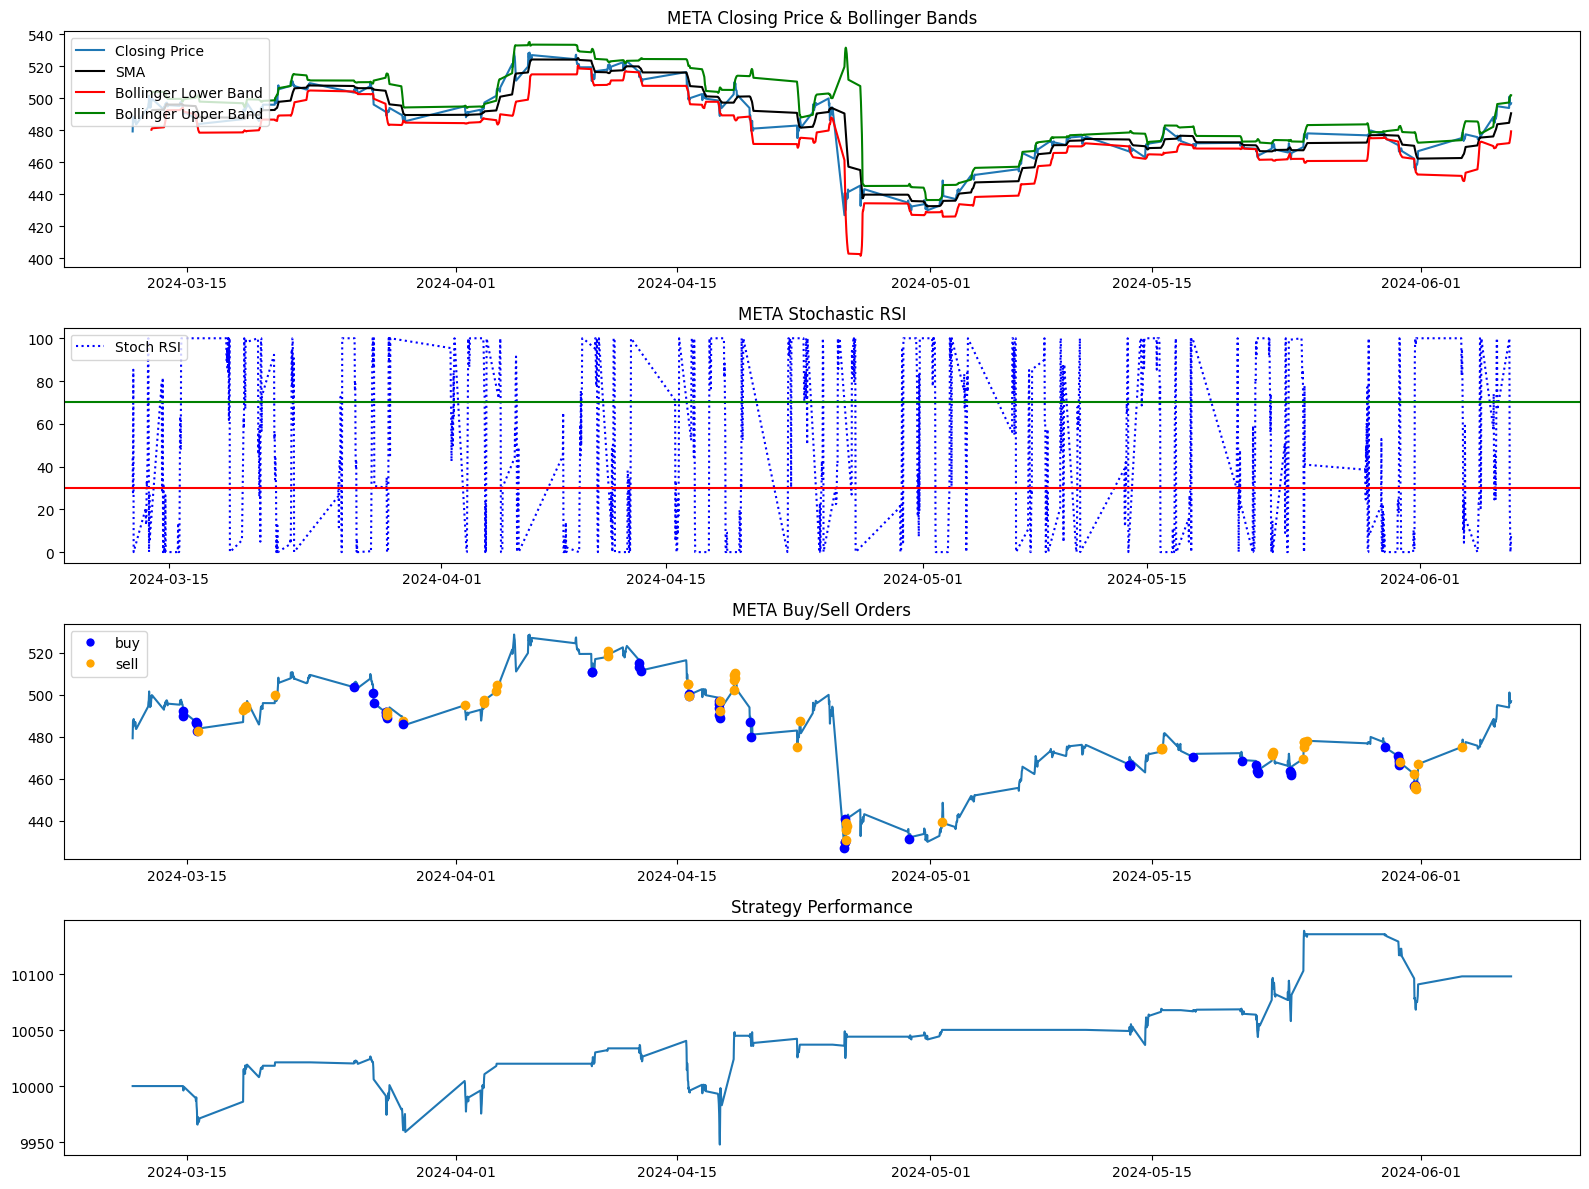

In [44]:
from trading import TradingBot

# Define bot parameters
args = {
    # Stochastic RSI Attributes
    'rsi_period': 14,
    'stochastic_period': 9,

    # Bollinger Band Attributes
    'simple_moving_average_period': 21,
    'bollinger_band_standard_deviation': 2,

    # Buy and Sell Attributes
    'ticker': 'META',  
    'stochastic_upper_band': 70,
    'stochastic_lower_band': 30,
    'time_look_back':  f'3 M', 
    'asset_interval': '30 mins', 
    'buy_quantity': 1, 
    'show_times': 500,
    'mode': 'backtest',
    'limit_percent': 0.015,
    'initial_cash': 1e4,
}

# Strategy performace already count commission fee
#  --> Even gain money, commision is more 
# Create and run bot
bot = TradingBot(ib, args)
while True:
    bot.backtest()
    break


In [45]:
def sharpe_ratio(rate):
    r_f = 0 # 0.005 / 252  # 0.5% (US Treasury)
    r_m = rate.mean()
    sigma = rate.std()
    return (r_m - r_f) / sigma

def get_returns(prices):
    return prices.pct_change()

In [46]:
print(f"sharpe_ratio(net_worth): {sharpe_ratio(get_returns(pd.Series(bot.net_worth)))}")
print(f"sharpe_ratio({bot.ticker}): {sharpe_ratio(get_returns(pd.Series(bot.closing_price_array)))}")

sharpe_ratio(net_worth): 0.02559799345691306
sharpe_ratio(META): 0.009459749929886983


In [47]:
def sortino_ratio(rate):
    r_f = 0  # Risk-free rate (assumed to be 0 for simplicity)
    r_m = rate.mean()
    downside_returns = rate[rate < r_f]
    downside_deviation = downside_returns.std()
    return (r_m - r_f) / downside_deviation

def get_returns(prices):
    return prices.pct_change()

# Assuming bot.net_worth and bot.closing_price_array are defined and are list-like objects
net_worth_series = pd.Series(bot.net_worth)
closing_price_series = pd.Series(bot.closing_price_array)

print(f"sortino_ratio(net_worth): {sortino_ratio(get_returns(net_worth_series))}")
print(f"sortino_ratio({bot.ticker}): {sortino_ratio(get_returns(closing_price_series))}")

sortino_ratio(net_worth): 0.0282150532921274
sortino_ratio(META): 0.008656332357461998
